# LatentMind V6 — Colab Notebook

**Training-first pipeline**: synthesizes agentic traces → trains the policy brain → loads the agent → runs tests.

The brain is a trained 3-head MLP. It picks one action at a time — rag · sql · chart · email · template — and re-decides after each step, stopping when its *continue* score drops below the seuil.

Requires: T4 or L4 GPU runtime.

In [1]:
# ─── GPU CLEANUP — run this any time before re-running the agent cells ───────
# Releases all model weights from VRAM so you can reload without OOM.
# Safe to run even on the very first pass (does nothing if nothing is loaded).

import gc, sys, torch

def cleanup(verbose: bool = True, _globals: dict | None = None) -> None:
    freed: list[str] = []

    # ── 1. delete notebook-level globals that hold model references ───────
    # The `agent` object wraps the LangGraph graph; its node closures call
    # get_slm() / get_polisher() / get_brain() — keeping tensors alive even
    # after we null the module-level singletons. Kill it first.
    _g = _globals or {}
    for name in ("agent", "slm"):
        if name in _g:
            del _g[name]
            freed.append(f"global:{name}")

    # ── 2. SLM — main model + 0.5B drafter + polisher ─────────────────────
    try:
        import v6.slm as _m
        slm_obj = _m._slm
        if slm_obj is not None:
            for tid in list(slm_obj._store.keys()):
                slm_obj.clear_thread(tid)
            if hasattr(slm_obj, "_draft") and slm_obj._draft is not None:
                del slm_obj._draft        # 0.5B drafter
                slm_obj._draft = None
                slm_obj._draft_tokenizer = None
            if hasattr(slm_obj, "model"):
                del slm_obj.model         # main 3B / 7B weights
            _m._slm = None
            freed.append("SLM (main + drafter)")
        pol_obj = _m._polisher
        if pol_obj is not None:
            if hasattr(pol_obj, "model"):
                del pol_obj.model
            _m._polisher = None
            freed.append("polisher")
    except Exception:
        pass

    # ── 3. BGE-M3 encoder + retriever ─────────────────────────────────────
    try:
        import v6.knowledge as _m
        enc_obj = _m._encoder
        if enc_obj is not None:
            if hasattr(enc_obj, "model"):
                del enc_obj.model
            _m._encoder = None
            freed.append("BGE-M3")
        _m._retriever = None
    except Exception:
        pass

    # ── 4. brain head + schema ─────────────────────────────────────────────
    try:
        import v6.brain as _m
        if _m._brain is not None:
            _m._brain = None
            freed.append("brain head")
    except Exception:
        pass
    try:
        import v6.schema as _m
        _m._schema = None
    except Exception:
        pass

    # ── 5. garbage-collect (multiple passes to break cycles) ──────────────
    for _ in range(3):
        gc.collect()

    # ── 6. release CUDA allocator cache ───────────────────────────────────
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

    if verbose:
        if freed:
            print("Released:", ", ".join(freed))
        else:
            print("Nothing was loaded — nothing to release")
        if torch.cuda.is_available():
            alloc = torch.cuda.memory_allocated() / 1e9
            total = torch.cuda.get_device_properties(0).total_memory / 1e9
            print(f"VRAM: {alloc:.2f} GB / {total:.1f} GB after cleanup")
        print("Ready to re-run the load cell.")

cleanup(verbose=True, _globals=globals())


Nothing was loaded — nothing to release
VRAM: 0.00 GB / 23.7 GB after cleanup
Ready to re-run the load cell.


In [2]:
# Core inference + RAG
!pip install 'transformers>=4.46.0' 'sentence-transformers>=3.0.0' 'accelerate>=0.27.0'
print("✓ transformers, sentence-transformers, accelerate")

# Graph + math
!pip install 'langgraph>=0.2.0' 'bitsandbytes>=0.43.0' scipy matplotlib
print("✓ langgraph, bitsandbytes, scipy, matplotlib")

# Utils
!pip install jinja2 pydantic pymysql mysql-connector-python
print("✓ jinja2, pydantic, mysql connectors")

print("\n✓ Setup complete! Ready to load agent.")

✓ transformers, sentence-transformers, accelerate
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 44.8 MB/s eta 0:00:00:00:0100:01
✓ langgraph, bitsandbytes, scipy, matplotlib
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.7/45.7 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.7/21.7 MB 98.3 MB/s eta 0:00:00:00:0100:01
✓ jinja2, pydantic, mysql connectors

✓ Setup complete! Ready to load agent.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os, subprocess, sys, shutil

REPO_URL = 'https://github.com/Hamza09Hamza/Latent-Djezzy.git'
REPO_DIR = '/content/Latent-Djezzy'
BRANCH   = 'v6-clean'

os.chdir('/content')

if os.path.isdir(os.path.join(REPO_DIR, '.git')):
    # Repo already present — pull latest without nuking trained models
    print('Repo found — pulling latest from origin/v6-clean ...')
    subprocess.run(['git', '-C', REPO_DIR, 'fetch', 'origin'], check=True)
    subprocess.run(['git', '-C', REPO_DIR, 'reset', '--hard', f'origin/{BRANCH}'], check=True)
    print('✓ repo updated to latest origin/v6-clean')
else:
    if os.path.isdir(REPO_DIR):
        shutil.rmtree(REPO_DIR)
        print('removed stale directory')
    subprocess.run(
        ['git', 'clone', '--depth=1', '--branch', BRANCH, REPO_URL, REPO_DIR],
        check=True)
    print(f'✓ cloned {BRANCH} → {REPO_DIR}')

# Flush any cached v6 modules so the freshly pulled code is picked up
for mod in list(sys.modules.keys()):
    if 'v6' in mod:
        del sys.modules[mod]

os.chdir(REPO_DIR)

# Show the exact commit so you can confirm you're on the latest
commit = subprocess.check_output(
    ['git', 'log', '--oneline', '-1'], cwd=REPO_DIR).decode().strip()
print(f'HEAD: {commit}')

head_path = 'models/brain_head.pt'
if os.path.isfile(head_path):
    size_mb = os.path.getsize(head_path) / 1e6
    print(f'✓ Trained brain head found ({size_mb:.1f} MB) — will skip training')
else:
    print('! Trained brain head NOT found — Cells 6-7 will build it (~2 min on T4)')


Mounted at /content/drive
✓ cloned v6-clean → /content/Latent-Djezzy
HEAD: 190d223 Fix Bug#2 (chart not analyzed) and Bug#3 (follow-up report loses wilaya)
! Trained brain head NOT found — Cells 6-7 will build it (~2 min on T4)


In [4]:
import shutil, os

# Database location — checks LatentDjezzy folder first, falls back to MyDrive root
LOCAL_DB   = "/content/interndb.sqlite"

possible_locations = [
    "/content/drive/MyDrive/LatentDjezzy/interndb.sqlite",
    "/content/drive/MyDrive/interndb.sqlite",
]

DRIVE_DB = None
for loc in possible_locations:
    if os.path.isfile(loc):
        DRIVE_DB = loc
        break

if not DRIVE_DB:
    print("⚠ Database not found in:")
    for loc in possible_locations:
        print(f"    {loc}")
    print("\nPlease ensure interndb.sqlite is in /MyDrive/LatentDjezzy/ or /MyDrive/")
else:
    if not os.path.isfile(LOCAL_DB):
        shutil.copy(DRIVE_DB, LOCAL_DB)
        print(f"✓ copied {os.path.getsize(LOCAL_DB):,} bytes → {LOCAL_DB}")
    else:
        print("✓ SQLite already present:", LOCAL_DB)

# Create output dirs on Drive so charts and emails are persisted
output_base = "/content/drive/MyDrive/LatentDjezzy/v6_output"
for d in [
    f"{output_base}/charts",
    f"{output_base}/emails",
    f"{output_base}/reports",
]:
    os.makedirs(d, exist_ok=True)
print(f"✓ Output dirs ready on Drive → {output_base}/")


✓ copied 40,271,872 bytes → /content/interndb.sqlite
✓ Output dirs ready on Drive → /content/drive/MyDrive/LatentDjezzy/v6_output/


In [5]:
import os, warnings, logging

warnings.filterwarnings("ignore")
logging.getLogger("transformers").setLevel(logging.ERROR)
os.environ["TRANSFORMERS_VERBOSITY"] = "error"

os.environ["V6_USE_SQLITE"]    = "1"
os.environ["V6_SQLITE_PATH"]   = "/content/interndb.sqlite"

# ── SQL generator model size ──────────────────────────────────────────────
# "3b"  → Qwen2.5-Coder-3B-Instruct     (~6.4 GB fp16)  — safe baseline
# "4b"  → Qwen3-4B-Instruct-2507        (~8.0 GB fp16)  ← current default
#          text-only, native Instruct, 262K ctx, no thinking mode.
#          drafter = Qwen3-0.6B (shared tokenizer, 2-4x speed)
# "7b"  → Qwen2.5-Coder-7B-Instruct     (~14 GB fp16)   — needs V6_4BIT=1
#
# Note: Qwen3.5-4B is the multimodal branch (vision+text) — model_type
# `qwen3_5` only ships in transformers from git main and there's no
# Instruct head. Stock Colab transformers can't load it. We use the
# pure-text Qwen3-4B-Instruct-2507 instead (transformers >= 4.51 OK).
os.environ["V6_SLM_SIZE"]       = "4b"

os.environ["V6_4BIT"]           = "0"   # "1" only needed for 7B on 16 GB T4
os.environ["V6_SPECULATIVE"]    = "1"   # drafter → 2-4x speed
os.environ["V6_CONSTRAINED_SQL"] = "0"

os.environ["V6_POLISHER_HUB_ID"] = "Qwen/Qwen2.5-1.5B-Instruct"
os.environ["V6_SLM_OVERRIDE"]   = ""
os.environ["V6_OUTPUT_DIR"]     = "/content/drive/MyDrive/LatentDjezzy/v6_output"
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

import torch
device   = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu"
total_gb = torch.cuda.get_device_properties(0).total_memory / 1e9 if torch.cuda.is_available() else 0
size  = os.environ.get("V6_SLM_SIZE", "4b")
quant = "4-bit" if os.environ.get("V6_4BIT") == "1" else "fp16"

_SLM_LABEL = {"3b": "Qwen2.5-Coder-3B", "4b": "Qwen3-4B-Instruct-2507", "7b": "Qwen2.5-Coder-7B"}
_SLM_GB    = {"3b": 6.4, "4b": 8.0, "7b": 7.0 if quant == "4-bit" else 14.0}
slm_gb     = _SLM_GB.get(size, 8.0)
draft_gb   = 1.2 if size in ("4b",) else 1.0
total_need = slm_gb + 3.0 + 2.3 + draft_gb + 1.0
headroom   = total_gb - total_need
status     = "✓ fits" if headroom >= 2.0 else "⚠ tight"

print(f"GPU:                {device}  ({total_gb:.1f} GB)")
print(f"SQL gen model:      {_SLM_LABEL.get(size, f'Qwen-{size}')} ({quant})")
print(f"Polisher (3-role):  {os.environ['V6_POLISHER_HUB_ID']}")
print(f"Speculative dec.:   {'✓ ON' if os.environ.get('V6_SPECULATIVE') == '1' else '✗ OFF'}")
print(f"Constrained SQL:    {'✓ ON' if os.environ.get('V6_CONSTRAINED_SQL') == '1' else '✗ OFF'}")
print(f"Output dir:         /content/drive/MyDrive/LatentDjezzy/v6_output")
print(f"\nVRAM budget: ~{total_need:.1f} GB needed / {total_gb:.1f} GB available  "
      f"({headroom:.1f} GB headroom  {status})")

GPU:                NVIDIA L4  (23.7 GB)
SQL gen model:      Qwen3-4B-Instruct-2507 (fp16)
Polisher (3-role):  Qwen/Qwen2.5-1.5B-Instruct
Speculative dec.:   ✓ ON
Constrained SQL:    ✗ OFF
Output dir:         /content/drive/MyDrive/LatentDjezzy/v6_output

VRAM budget: ~15.5 GB needed / 23.7 GB available  (8.2 GB headroom  ✓ fits)


In [6]:
import os

# Set True to re-synthesize traces even if brain_head.pt already exists.
# Always set True after pulling new code that changed brain_data.py.
FORCE_RETRAIN = True

head_path = 'models/brain_head.pt'
if not FORCE_RETRAIN and os.path.isfile(head_path):
    print('Skipping trace synthesis (FORCE_RETRAIN=False and head already exists)')
else:
    # Synthesize agentic traces — the editable policy spec — for the brain.
    # Output: v6/data/brain_train.jsonl
    print('Synthesizing agentic traces...')
    !python3 -m v6.brain_data
    !echo "Rows in brain_train.jsonl:" && wc -l v6/data/brain_train.jsonl


Synthesizing agentic traces...
wrote 8028 training rows → /content/Latent-Djezzy/v6/data/brain_train.jsonl
  by intent       : {'data': 7644, 'meta': 26, 'unanswerable': 71, 'definition': 248, 'greeting': 39}
  by action label : {'chart': 290, 'sql': 1878, 'rag': 1832, 'email': 330, 'template': 380}
  continue 0/1    : 3318 stop / 4710 go
  next: python3 -m v6.train_brain
Rows in brain_train.jsonl:
8028 v6/data/brain_train.jsonl


In [7]:
import os

# Set True to retrain even if brain_head.pt already exists.
FORCE_RETRAIN = True

head_path = 'models/brain_head.pt'
if not FORCE_RETRAIN and os.path.isfile(head_path):
    print('Brain head already trained; skipping (set FORCE_RETRAIN=True to redo)')
else:
    if os.path.isfile(head_path):
        os.remove(head_path)  # remove stale checkpoint before retraining
    # Train the 3-head MLP (intent · action · continue).
    # 200 epochs on the 8k-row dataset ~ 3-4 min on T4.
    # Output: models/brain_head.pt
    print('Training brain head (200 epochs)...')
    !python3 -m v6.train_brain --epochs 200

if os.path.isfile(head_path):
    print('\n✓ Brain ready:', head_path)
else:
    print('\n✗ Training did not produce', head_path, '— check the log above')


Training brain head (200 epochs)...
loaded 8028 rows; encoding with BGE-M3 (one-time)...
config.json: 100% 687/687 [00:00<00:00, 4.01MB/s]
tokenizer_config.json: 100% 444/444 [00:00<00:00, 2.18MB/s]
sentencepiece.bpe.model: 100% 5.07M/5.07M [00:01<00:00, 4.13MB/s]
tokenizer.json: 100% 17.1M/17.1M [00:00<00:00, 41.5MB/s]
special_tokens_map.json: 100% 964/964 [00:00<00:00, 6.91MB/s]
pytorch_model.bin: 100% 2.27G/2.27G [00:06<00:00, 378MB/s]
Loading weights: 100% 391/391 [00:00<00:00, 1164.18it/s, Materializing param=pooler.dense.weight]                               
model.safetensors: 100% 2.27G/2.27G [00:08<00:00, 270MB/s]
  epoch  40 | loss 1.5197 | val intent 0.880 | action 0.983 | continue 0.834
  epoch  80 | loss 0.4706 | val intent 0.978 | action 0.993 | continue 0.917
  epoch 120 | loss 0.2524 | val intent 0.988 | action 0.999 | continue 0.939
  epoch 160 | loss 0.1720 | val intent 0.994 | action 0.999 | continue 0.949
  epoch 200 | loss 0.1294 | val intent 0.998 | action 0.999 |

In [8]:
import sys, os, torch
sys.path.insert(0, "/content/Latent-Djezzy")

# Free any previously loaded models before (re-)loading — prevents OOM on re-run
try:
    cleanup(verbose=False, _globals=globals())
except NameError:
    pass  # cleanup not defined yet (first run) — fine

from v6.graph import LatentMindV6
from v6.slm import get_slm, get_polisher
from v6.brain import get_brain

print("Loading BGE-M3 encoder + SLM (downloads on first run)…")
agent = LatentMindV6()
get_slm()    # force-load the main model so VRAM is allocated before queries
get_brain()  # force-load the trained brain head (fails fast if not trained)

print("\nLoading polisher (1.5B — natural-language refiner)…")
try:
    get_polisher()
    print("✓ Polisher ready")
except Exception as _e:
    print(f"  Polisher unavailable ({_e}) — raw answers will be shown instead")

if torch.cuda.is_available():
    alloc_gb = torch.cuda.memory_allocated() / 1e9
    total_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"\nGPU: {alloc_gb:.1f} GB / {total_gb:.1f} GB  "
          f"(headroom ~{total_gb - alloc_gb:.1f} GB)")


Loading BGE-M3 encoder + SLM (downloads on first run)…


config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

✓ Polisher ready

GPU: 15.0 GB / 23.7 GB  (headroom ~8.7 GB)


In [9]:
from v6.config import V6Config

print("\n" + "="*60)
print("Configuration Verification")
print("="*60)
print(f"SLM size:             {V6Config.SLM_SIZE}")
print(f"SLM model:            {V6Config.slm_id()}")
print(f"Polisher:             {V6Config.POLISHER_HUB_ID}")
print(f"4-bit quantization:   {'✓ Enabled' if V6Config.USE_4BIT else '✗ Disabled'}")
print(f"Constrained SQL:      {'✓ ON' if V6Config.USE_CONSTRAINED_SQL else '✗ OFF'}")
print(f"Brain head:           {V6Config.BRAIN_HEAD_PATH}")
print(f"Brain seuil:          {V6Config.BRAIN_SEUIL}  (continue ≥ this → keep going)")
print(f"Brain max steps:      {V6Config.BRAIN_MAX_STEPS}")
print("="*60 + "\n")
print("Ready to run queries. Try: ask('Hello, what can you do?')")


Configuration Verification
SLM size:             4b
SLM model:            Qwen/Qwen3-4B-Instruct-2507
Polisher:             Qwen/Qwen2.5-1.5B-Instruct
4-bit quantization:   ✗ Disabled
Constrained SQL:      ✗ OFF
Brain head:           /content/Latent-Djezzy/models/brain_head.pt
Brain seuil:          0.5  (continue ≥ this → keep going)
Brain max steps:      8

Ready to run queries. Try: ask('Hello, what can you do?')


In [ ]:
import time, os, sys
from v6.state import initial_state
from IPython.display import display, Image, Markdown

_DIM, _RESET = "\033[2m", "\033[0m"

def _type(text, delay=0.005):
    for ch in text:
        sys.stdout.write(ch)
        sys.stdout.flush()
        time.sleep(delay)

def ask(question, thread="main"):
    # One turn: stream the brain's thinking, then the terminal response.
    # The terminal has 3 roles:
    #   Analyst  → SQL data rows → insightful paragraph (same language as query)
    #   Polisher → RAG / definition / greeting → natural rewrite
    #   Clarifier→ errors or missing info → helpful question
    config = {"configurable": {"thread_id": thread}, "recursion_limit": 60}
    state  = initial_state(question, thread)

    print(f"\n{'='*60}")
    print(f"Q: {question}")
    print(f"{'='*60}")
    t0 = time.time()

    shown = 0
    final_answer  = ""
    chart_path    = ""
    document_path = ""
    email_draft   = None
    intent        = ""
    timings       = {}

    for event in agent.graph.stream(state, config=config, stream_mode="updates"):
        for node, data in event.items():
            if not data:
                continue
            thoughts = data.get("thoughts")
            if thoughts and len(thoughts) > shown:
                for th in thoughts[shown:]:
                    if th.get("kind") == "thinking":
                        sys.stdout.write(_DIM + "  💭 ")
                        _type(th["text"])
                        print(_RESET)
                shown = len(thoughts)
            if data.get("timings"):
                timings = data["timings"]
            if node == "brain":
                intent = data.get("intent", intent)
                act    = data.get("next_action", "")
                cont   = data.get("continue_score", 0.0)
                print(f"{_DIM}     → {act}  (continue {cont:.2f}){_RESET}")
            elif node == "chart":
                chart_path = data.get("chart_path", "") or chart_path
            elif node == "template":
                document_path = data.get("document_path", "") or document_path
            elif node == "email":
                email_draft = data.get("email_draft") or email_draft
            elif node == "communicator":
                final_answer = data.get("final_answer", "")

    elapsed = time.time() - t0

    # ── 3-role terminal ───────────────────────────────────────────────────
    print(f"\nAnswer ({elapsed:.1f}s):")
    from v6.slm import get_polisher

    # "not sure which kpi" is intentional clarification — NOT a failure.
    _FAILURE = ("couldn't build", "failed to run", "no matching rows",
                "wasn't able to pull")
    is_failure = any(p in (final_answer or "").lower() for p in _FAILURE)
    email_no_recipient = bool(email_draft and email_draft.get("status") != "draft")

    def _stream_role(text, role):
        try:
            for tok in get_polisher().stream(text, question, role=role):
                print(tok, end="", flush=True)
            print()
        except Exception:
            print(text)

    if is_failure:
        # Clarifier explains what went wrong and asks for what's needed
        _stream_role(final_answer, "clarify")
    elif email_no_recipient:
        # Analyze data (if present) then ask for a recipient.
        # SQL data → always "analyze" (the Analyst handles any row count;
        # the Polisher is for RAG text, not numbers).
        data_part = (final_answer or "").split("📧")[0].strip()
        if data_part:
            _stream_role(data_part, "analyze")
        _stream_role(
            "An email was drafted but no recipient was identified in the request.",
            "clarify")
    elif intent in ("greeting", "meta"):
        _stream_role(final_answer, "polish")
    elif intent == "definition" and final_answer:
        _stream_role(final_answer, "polish")
    elif intent == "data" and final_answer and not is_failure:
        if email_draft and email_draft.get("status") == "draft":
            # Email drafted — analyze the data part first (always "analyze":
            # single-value or multi-row, the Analyst handles both), then show draft.
            data_part = (final_answer or "").split("📧")[0].strip()
            if data_part:
                _stream_role(data_part, "analyze")
        elif document_path:
            # Report generated — the document IS the analysis; just print the
            # confirmation message (e.g. "Report generated from prior result.")
            print(final_answer or "(no answer)")
        else:
            # Pure data OR chart — always "analyze".
            # The Polisher is for RAG/definitions/greetings, NOT for numbers.
            # Analyst handles 1-row ("Batna ARPU: 450") and multi-row equally well.
            _stream_role(final_answer, "analyze")
    else:
        print(final_answer or "(no answer)")

    # ── display chart inline ──────────────────────────────────────────────
    if chart_path and os.path.isfile(chart_path):
        print()
        display(Image(chart_path))
    elif chart_path:
        print(f"  (chart path reported but file missing: {chart_path})")

    # ── report ────────────────────────────────────────────────────────────
    if document_path:
        print(f"  Report saved → {document_path}")

    # ── email draft + save to Drive ───────────────────────────────────────
    if email_draft:
        print()
        to = email_draft.get("to") or "(no recipient — please specify one)"
        display(Markdown(f"**Email draft**\n\n"
                         f"**To:** {email_draft.get('to_name', '?')} <{to}>  \n"
                         f"**Subject:** {email_draft.get('subject', '')}\n\n"
                         f"---\n\n{email_draft.get('body', '')}"))
        try:
            import datetime
            from v6.config import V6Config
            email_dir = os.path.join(V6Config.output_dir(), "emails")
            os.makedirs(email_dir, exist_ok=True)
            stamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
            email_path = os.path.join(email_dir, f"email_{stamp}.txt")
            with open(email_path, "w") as f:
                f.write(f"To: {email_draft.get('to_name', '?')} <{to}>\n")
                f.write(f"Subject: {email_draft.get('subject', '')}\n\n")
                f.write(email_draft.get("body", ""))
            print(f"  Email saved → {email_path}")
        except Exception as e:
            print(f"  (could not save email: {e})")

    # ── performance breakdown ─────────────────────────────────────────────
    import torch
    brain_ms = sum(v for k, v in timings.items() if k.startswith("brain"))
    sql_ms   = sum(v for k, v in timings.items() if k.startswith("sql"))
    rag_ms   = timings.get("rag_ms", 0.0)
    n_ticks  = sum(1 for k in timings if k.startswith("brain"))
    line = (f"⏱  {n_ticks} brain ticks {brain_ms:.0f}ms · "
            f"rag {rag_ms / 1000:.2f}s · sql {sql_ms / 1000:.2f}s · "
            f"total {elapsed:.1f}s")
    if torch.cuda.is_available():
        line += f" · VRAM {torch.cuda.memory_allocated() / 1e9:.1f} GB"
    print(f"{_DIM}{line}{_RESET}")

    # ── free the KV cache ─────────────────────────────────────────────────
    try:
        from v6.slm import get_slm
        get_slm().clear_thread(thread)
    except Exception:
        pass
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    print()


In [11]:
# Greeting in French
ask("Salam, qu'est-ce que tu peux faire ?")


Q: Salam, qu'est-ce que tu peux faire ?
  💭 Let me answer that directly.
     → rag  (continue 0.19)

Answer (0.5s):
Salut ! Je suis LatentMind V6, un agent de données numériques pour le marché algérien du telecom. Je m'appuie sur mon système de recherche pour analyser les données et générer des rapports. Je peux vous aider avec des informations sur KPIs, tendances, comparaisons ou décompositions par wilaya, période ou segment.
⏱  1 brain ticks 368ms · rag 0.00s · sql 0.00s · total 0.5s · VRAM 15.0 GB



In [12]:
# Definition — no sql
ask("What does EBITDA margin mean?")


Q: What does EBITDA margin mean?
  💭 Let me check the reference knowledge first.
     → rag  (continue 0.95)

Answer (1.5s):
The EBITDA margin is a financial metric that represents the percentage of a company's total revenue that is attributable to its earnings before interest, taxes, depreciation, and amortization. It's commonly used to measure a company's operational efficiency and financial performance. When you're looking at the KPI 'ebitda_margin' in the table fpa_profitability, this metric can provide insights into how effectively your company is generating profit from its core business operations.
⏱  1 brain ticks 37ms · rag 0.00s · sql 0.00s · total 1.5s · VRAM 15.0 GB



In [13]:
# fpa_profitability, Batna, relative time
ask("Show me the gross margin for Batna last quarter")


Q: Show me the gross margin for Batna last quarter
  💭 Let me check the reference knowledge first.
     → rag  (continue 1.00)
  💭 Pulled reference knowledge (grounding 0.56).
  💭 I'll query the database for the numbers.
     → sql  (continue 0.99)
  💭 Mapped it to tables: ['fpa_profitability', 'dim_location'].
  💭 Resolved wilayas: Batna=61 communes.
  💭 Built the query: SELECT AVG(f.gross_margin) AS avg_gross_margin
FROM fpa_profitability f
WHERE f.location_id IN (
    SELECT location_id 
    FROM dim_location 
    WHERE wilaya = 'Batna'
)
  AND f.week_start >= '2026-01-01' 
  AND f.week_start < '2026-04-01' LIMIT 1000
  💭 Ran it — 1 row(s) back.
  💭 I have what I need — writing the answer now.
     → email  (continue 0.04)

Answer (17.4s):
For Batna's last quarter, the gross margin was 40.0941%.
⏱  3 brain ticks 40ms · rag 0.02s · sql 14.31s · total 17.4s · VRAM 15.8 GB



In [14]:
# prepaid_kpi, ranking
ask("Which wilaya had the highest prepaid recharge rate in 2025?")


Q: Which wilaya had the highest prepaid recharge rate in 2025?
  💭 Let me check the reference knowledge first.
     → rag  (continue 1.00)
  💭 Pulled reference knowledge (grounding 0.54).
  💭 I'll query the database for the numbers.
     → sql  (continue 0.99)
  💭 Mapped it to tables: ['prepaid_kpi', 'dim_location'].
  💭 Built the query: SELECT dl.wilaya, AVG(p.recharge_rate) AS avg_recharge_rate
FROM prepaid_kpi p
JOIN dim_location dl ON p.location_id = dl.location_id
WHERE p.week_start >= '2025-01-01' AND p.week_start < '2026-01-01'
GROUP BY dl.wilaya
ORDER BY avg_recharge_rate DESC
LIMIT 1
  💭 Ran it — 1 row(s) back.
  💭 I have what I need — writing the answer now.
     → email  (continue 0.04)

Answer (15.1s):
In 2025, the wilaya with the highest prepaid recharge rate was Touggourt, with an average recharge rate of 41.6760.
⏱  3 brain ticks 39ms · rag 0.02s · sql 12.12s · total 15.1s · VRAM 15.8 GB




Q: Plot the net income trend for Tlemcen and Setif over 2025
  💭 Let me check the reference knowledge first.
     → rag  (continue 1.00)
  💭 Pulled reference knowledge (grounding 0.42).
  💭 I'll query the database for the numbers.
     → sql  (continue 1.00)
  💭 Mapped it to tables: ['fpa_profitability', 'dim_location'].
  💭 Resolved wilayas: Tlemcen=53 communes, Sétif=60 communes.
  💭 Built the query: SELECT dl.wilaya, strftime('%Y-%m-01', f.week_start) AS month_start, SUM(f.net_income) AS net_income
FROM fpa_profitability f
JOIN dim_location dl ON f.location_id = dl.location_id
WHERE f.location_id IN (
    SELECT location_id FROM dim_location WHERE wilaya IN ('Tlemcen', 'Sétif')
)
  AND f.week_start >= '2025-01-01' AND f.week_start < '2026-01-01'
GROUP BY dl.wilaya, month_start
ORDER BY month_start ASC LIMIT 1000
  💭 Ran it — 12 row(s) back.
  💭 The data's in — let me turn it into a chart.
     → chart  (continue 0.88)
  💭 Chart saved.
  💭 I have what I need — writing the answer now

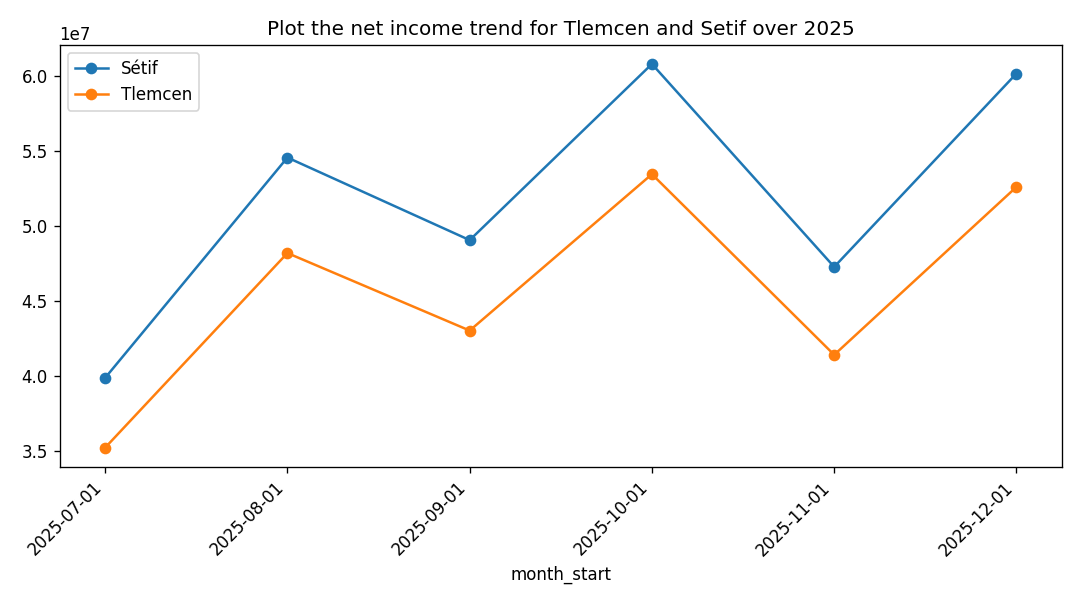

⏱  4 brain ticks 40ms · rag 0.02s · sql 17.54s · total 22.2s · VRAM 15.8 GB



In [15]:
# Chart trend, two wilayas
ask("Plot the net income trend for Tlemcen and Setif over 2025")

In [16]:
# opex_capex table
ask("What's the capex breakdown for IT and network this year?")


Q: What's the capex breakdown for IT and network this year?
  💭 Let me check the reference knowledge first.
     → rag  (continue 1.00)
  💭 Pulled reference knowledge (grounding 0.59).
  💭 I'll query the database for the numbers.
     → sql  (continue 0.99)
  💭 Mapped it to tables: ['opex_capex'].
  💭 Built the query: SELECT SUM(capex_it) AS total_capex_it, SUM(capex_network) AS total_capex_network
FROM opex_capex
WHERE week_start >= '2026-01-01' AND week_start < '2027-01-01' LIMIT 1000
  💭 Ran it — 1 row(s) back.
  💭 I have what I need — writing the answer now.
     → email  (continue 0.02)

Answer (13.4s):
This year, the capital expenditure (CapEx) breakdown for IT and network is as follows:

- Total CapEx for IT: $1,016,277,038.28
- Total CapEx for Network: $3,394,219,086.67

That's a significant investment in both areas!
⏱  3 brain ticks 42ms · rag 0.02s · sql 11.02s · total 13.4s · VRAM 15.8 GB



In [17]:
# migration_rate, postpaid_kpi
ask("How many postpaid subscribers migrated in Bejaia last month?")


Q: How many postpaid subscribers migrated in Bejaia last month?
  💭 Let me check the reference knowledge first.
     → rag  (continue 1.00)
  💭 Pulled reference knowledge (grounding 0.60).
  💭 I'll query the database for the numbers.
     → sql  (continue 0.99)
  💭 Mapped it to tables: ['postpaid_kpi', 'dim_location'].
  💭 Resolved wilayas: Béjaïa=52 communes.
  💭 Built the query: SELECT AVG(p.migration_rate) AS avg_migration_rate
FROM postpaid_kpi p
JOIN dim_location dl ON p.location_id = dl.location_id
WHERE dl.wilaya = 'Béjaïa'
  AND p.week_start >= '2026-04-01' AND p.week_start < '2026-05-01' LIMIT 1000
  💭 Ran it — 1 row(s) back.
  💭 I have what I need — writing the answer now.
     → email  (continue 0.06)

Answer (15.8s):
In Bejaia last month, approximately 0.9057 postpaid subscribers migrated.
⏱  3 brain ticks 44ms · rag 0.02s · sql 12.82s · total 15.8s · VRAM 15.8 GB



In [18]:
# Follow-up — wilaya only
ask("and for Tiaret?")


Q: and for Tiaret?
  💭 Let me check the reference knowledge first.
     → rag  (continue 0.98)
  💭 Pulled reference knowledge (grounding 0.00).
  💭 I'll query the database for the numbers.
     → sql  (continue 0.99)
  💭 Mapped it to tables: ['postpaid_kpi', 'dim_location'].
  💭 Resolved wilayas: Tiaret=42 communes.
  💭 Built the query: SELECT AVG(p.migration_rate) AS avg_migration_rate
FROM postpaid_kpi p
JOIN dim_location dl ON p.location_id = dl.location_id
WHERE p.location_id IN (SELECT location_id FROM dim_location WHERE wilaya = 'Tiaret')
  AND p.week_start >= '2026-04-01' AND p.week_start < '2026-05-01' LIMIT 1000
  💭 Ran it — 1 row(s) back.
  💭 I have what I need — writing the answer now.
     → email  (continue 0.00)

Answer (18.3s):
Pour Tiaret, la vitesse moyenne d'intégration est de 0.9218.
⏱  3 brain ticks 48ms · rag 0.02s · sql 15.01s · total 18.3s · VRAM 15.9 GB



In [19]:
# Follow-up — template only
ask("Put it in a report")


Q: Put it in a report
  💭 Let me check the reference knowledge first.
     → rag  (continue 1.00)
  💭 Report saved.
  💭 I have what I need — writing the answer now.
     → template  (continue 0.41)

Answer (0.6s):
Report generated from the previous query result.

📄 Report saved: /content/drive/MyDrive/LatentDjezzy/v6_output/reports/report_20260526_135404.md
  Report saved → /content/drive/MyDrive/LatentDjezzy/v6_output/reports/report_20260526_135404.md
⏱  2 brain ticks 47ms · rag 0.00s · sql 0.00s · total 0.6s · VRAM 15.0 GB



In [20]:
# global_revenue + email
ask("Email the B2B revenue breakdown to the finance director")


Q: Email the B2B revenue breakdown to the finance director
  💭 Let me check the reference knowledge first.
     → rag  (continue 1.00)
  💭 Pulled reference knowledge (grounding 0.68).
  💭 I'll query the database for the numbers.
     → sql  (continue 1.00)
  💭 Mapped it to tables: ['global_revenue', 'dim_location'].
  💭 Built the query: SELECT dl.wilaya, SUM(g.revenue_b2b) AS total_revenue_b2b
FROM global_revenue g
JOIN dim_location dl ON g.location_id = dl.location_id
GROUP BY dl.wilaya
ORDER BY total_revenue_b2b DESC LIMIT 1000
  💭 Ran it — 58 row(s) back.
  💭 Let me draft an email with these results.
     → email  (continue 0.99)
  💭 Drafted an email to boukader hamza.
  💭 I have what I need — writing the answer now.
     → email  (continue 0.19)

Answer (14.6s):
Tizi Ouzou leads with a total B2B revenue of 649.4M DZD, followed by Médéa at 622.5M DZD. Batna and Sétif both report revenues of 594.4M DZD, with Alger and Tlemcen reporting 557.8M DZD and 511.9M DZD respectively.



**Email draft**

**To:** boukader hamza <boukaderhamza71@gmail.com>  
**Subject:** Telecom analytics: Email the B2B revenue breakdown to the finance director

---

Hi boukader hamza,

Here are the analytics figures you asked for.

58 rows returned:
  wilaya: Tizi Ouzou | total_revenue_b2b: 649,429,794.52
  wilaya: Médéa | total_revenue_b2b: 622,512,728.11
  wilaya: Batna | total_revenue_b2b: 594,357,723.98
  wilaya: Sétif | total_revenue_b2b: 571,690,631.51
  wilaya: Alger | total_revenue_b2b: 557,762,185.53
  wilaya: Tlemcen | total_revenue_b2b: 511,997,718.59
  wilaya: Sidi Bel Abbès | total_revenue_b2b: 500,055,378.78
  wilaya: Béjaïa | total_revenue_b2b: 497,167,780.12
  ... (50 more rows)

| wilaya | total_revenue_b2b |
| --- | --- |
| Tizi Ouzou | 649,429,794.52 |
| Médéa | 622,512,728.11 |
| Batna | 594,357,723.98 |
| Sétif | 571,690,631.51 |
| Alger | 557,762,185.53 |
| Tlemcen | 511,997,718.59 |
| Sidi Bel Abbès | 500,055,378.78 |
| Béjaïa | 497,167,780.12 |
| Mascara | 458,462,894.46 |
| M'Sila | 454,114,339.97 |
| Bouira | 435,025,412.34 |
| Tiaret | 410,303,119.58 |
| Relizane | 374,117,849.81 |
| Skikda | 368,053,714.59 |
| Djelfa | 349,057,267.56 |

_(43 more rows not shown)_

Best regards,
LatentMind V6 — automated analytics assistant

---
This message was drafted automatically from the query:
  "Email the B2B revenue breakdown to the finance director"
Review the figures before sending.

  Email saved → /content/drive/MyDrive/LatentDjezzy/v6_output/emails/email_20260526_135423.txt
⏱  4 brain ticks 45ms · rag 0.02s · sql 10.60s · total 14.6s · VRAM 15.8 GB



In [21]:
# Unanswerable fake KPI
ask("What is the brand sentiment score for Oran?")


Q: What is the brand sentiment score for Oran?
  💭 Let me check the reference knowledge first.
     → rag  (continue 0.97)

Answer (0.3s):
That metric isn't in the database. I can answer questions about revenue, ARPU, churn, subscribers, EBITDA, OPEX, CAPEX, or profitability — for any Algerian wilaya or time period.
⏱  1 brain ticks 46ms · rag 0.00s · sql 0.00s · total 0.3s · VRAM 15.0 GB




Q: Chart the OPEX breakdown by category for Q3 2025 and email it
  💭 Let me check the reference knowledge first.
     → rag  (continue 1.00)
  💭 Pulled reference knowledge (grounding 0.58).
  💭 I'll query the database for the numbers.
     → sql  (continue 1.00)
  💭 Mapped it to tables: ['opex_capex'].
  💭 Built the query: SELECT 
    SUM(opex_network) AS total_opex_network,
    SUM(opex_marketing) AS total_opex_marketing,
    SUM(opex_distribution) AS total_opex_distribution,
    SUM(opex_support) AS total_opex_support,
    SUM(opex_it) AS total_opex_it
FROM opex_capex
WHERE week_start >= '2025-07-01' AND week_start < '2025-10-01' LIMIT 1000
  💭 Ran it — 1 row(s) back.
  💭 The data's in — let me turn it into a chart.
     → chart  (continue 0.90)
  💭 Chart saved.
  💭 Let me draft an email with these results.
     → email  (continue 0.90)
  💭 Drafted an email to Sarah Jones.
  💭 I have what I need — writing the answer now.
     → email  (continue 0.04)

Answer (22.1s):
To chart the OP

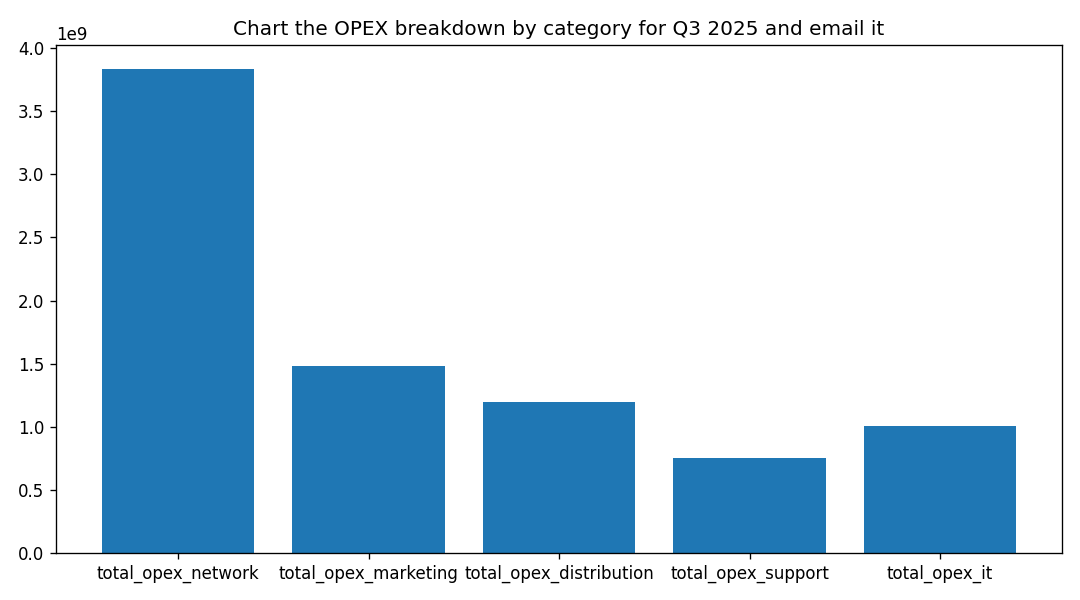

**Email draft**

**To:** Sarah Jones <sarah.jones@company.com>  
**Subject:** Telecom analytics: Chart the OPEX breakdown by category for Q3 2025 and email it

---

Hi Sarah Jones,

Here are the analytics figures you asked for.

total_opex_network: 3,831,459,911.15 | total_opex_marketing: 1,485,291,769.15 | total_opex_distribution: 1,195,110,638.83 | total_opex_support: 751,935,445.65 | total_opex_it: 1,004,516,026.00

| total_opex_network | total_opex_marketing | total_opex_distribution | total_opex_support | total_opex_it |
| --- | --- | --- | --- | --- |
| 3,831,459,911.15 | 1,485,291,769.15 | 1,195,110,638.83 | 751,935,445.65 | 1,004,516,026.00 |

Best regards,
LatentMind V6 — automated analytics assistant

---
This message was drafted automatically from the query:
  "Chart the OPEX breakdown by category for Q3 2025 and email it"
Review the figures before sending.

  Email saved → /content/drive/MyDrive/LatentDjezzy/v6_output/emails/email_20260526_135453.txt
⏱  5 brain ticks 50ms · rag 0.02s · sql 17.16s · total 22.1s · VRAM 15.9 GB



In [ ]:
# Multi-capability, opex_capex
ask("Chart the OPEX breakdown by category for Q3 2025 and email it to the finance director ")

In [23]:
# Times agent.graph.invoke directly (no UI polish / typewriter) so the numbers
# are the real engine cost. The brain MLP is milliseconds — the SLM dominates.
import time, torch
from v6.state import initial_state
from v6.slm import get_slm

BENCH = [
    "Salam, qu'est-ce que tu peux faire ?",
    "What does EBITDA margin mean?",
    "Show me the gross margin for Batna last quarter",
    "Which wilaya had the highest prepaid recharge rate in 2025?",
    "Plot the net income trend for Tlemcen and Setif over 2025",
    "Email the B2B revenue breakdown to the finance director",
]

hdr = f"{'query':<46}{'intent':<11}{'steps':>6}{'brain':>9}{'sql':>9}{'total':>9}"
print(hdr)
print("-" * len(hdr))
tot = 0.0
for q in BENCH:
    t0 = time.time()
    r = agent.graph.invoke(
        initial_state(q, "bench"),
        {"configurable": {"thread_id": "bench"}, "recursion_limit": 60})
    dt = time.time() - t0
    tot += dt
    tm = r.get("timings", {})
    brain_ms = sum(v for k, v in tm.items() if k.startswith("brain"))
    sql_ms   = sum(v for k, v in tm.items() if k.startswith("sql"))
    print(f"{q[:46]:<46}{r.get('intent',''):<11}"
          f"{r.get('brain_step',0):>6}{brain_ms:>7.0f}ms"
          f"{sql_ms/1000:>8.2f}s{dt:>8.2f}s")
    get_slm().clear_thread("bench")
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("-" * len(hdr))
print(f"{'AVERAGE per query':<46}{'':<11}{'':>6}{'':>9}{'':>9}"
      f"{tot/len(BENCH):>8.2f}s")
if torch.cuda.is_available():
    a = torch.cuda.memory_allocated() / 1e9
    t = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"\nVRAM: {a:.2f} GB used / {t:.1f} GB total  ({t-a:.1f} GB free)")
    print("Brain overhead is the 'brain' column — a few ms per query; the "
          "SLM router+sqlgen is the cost centre.")

query                                         intent      steps    brain      sql    total
------------------------------------------------------------------------------------------
Salam, qu'est-ce que tu peux faire ?          meta            1     19ms    0.00s    0.02s
What does EBITDA margin mean?                 definition      1     34ms    0.00s    0.06s
Show me the gross margin for Batna last quartedata            3     37ms   14.37s   14.44s
Which wilaya had the highest prepaid recharge data            3     37ms   12.22s   12.29s
Plot the net income trend for Tlemcen and Setidata            4     39ms   17.56s   17.79s
Email the B2B revenue breakdown to the financedata            4     41ms   12.47s   13.53s
------------------------------------------------------------------------------------------
AVERAGE per query                                                                    9.69s

VRAM: 14.98 GB used / 23.7 GB total  (8.7 GB free)
Brain overhead is the 'brain' column —

In [24]:
import torch
if torch.cuda.is_available():
    alloc  = torch.cuda.memory_allocated() / 1e9
    reserv = torch.cuda.memory_reserved()  / 1e9
    total  = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU  allocated: {alloc:.2f} GB")
    print(f"GPU  reserved:  {reserv:.2f} GB")
    print(f"GPU  total:     {total:.2f} GB")

GPU  allocated: 14.98 GB
GPU  reserved:  15.03 GB
GPU  total:     23.66 GB


In [25]:
# Direct streaming — bypasses the graph, useful for quick SLM checks.
from v6.slm import get_slm

slm = get_slm()
messages = [
    {"role": "system", "content": "You are a helpful telecom analyst."},
    {"role": "user",   "content": "List the top 3 KPIs for a telecom operator."},
]
print("Streaming response:")
for token in slm.stream_generate(messages, max_new_tokens=256):
    print(token, end="", flush=True)
print()

Streaming response:
Certainly! For a telecom operator, the top 3 Key Performance Indicators (KPIs) are critical to measuring service quality, customer satisfaction, and operational efficiency. These KPIs are:

1. **Network Availability and Uptime**  
   - Measures the percentage of time the network is operational and accessible to customers.  
   - Typically expressed as a percentage (e.g., 99.9% uptime).  
   - Importance: High availability ensures reliable connectivity, which directly impacts customer experience and trust.

2. **Customer Satisfaction (CSAT) or Net Promoter Score (NPS)**  
   - CSAT measures how satisfied customers are with services (e.g., call quality, speed, support).  
   - NPS gauges customer loyalty and willingness to recommend the operator.  
   - Importance: Reflects the quality of service delivery and helps identify areas for improvement in customer experience.

3. **Average Revenue Per User (ARPU)**  
   - Measures the average revenue generated per customer. 